In [78]:
import numpy as np

# Asset Information
mu = np.array([0.04,0.08,0.06,0.1])
sigma = np.array([0.05,0.2,0.12,0.25])

rho = np.array([
    [1.00,0.20,0.15,0.05],
    [0.20,1.00,0.60,0.40],
    [0.15,0.60,1.00,0.30],
    [0.05,0.40,0.30,1.00]
])

# Covariance Matrix
sigma_diag = np.diag(sigma)
Sigma = sigma_diag @ rho @ sigma_diag
print("covariance sigma:\n",Sigma.round(6))

# Compute the inverse covariance matrix
one = np.ones(4)
Sigma_inv = np.linalg.inv(Sigma)
print("Inverse covariance sigma: \n", Sigma_inv.round(6))

# Compute the GMV portfolio weights:
Weight_op_numerator = Sigma_inv @ one
Weight_op_denominator = one.T @ Sigma_inv @ one
Weight_op_gmv = Weight_op_numerator / Weight_op_denominator
print(
    " Weight of global minimum variance: \n", 
    Weight_op_gmv.round(4)
)

# Check that the portfolio weights sum to 1
print(" \n === Bonds  Equity  Real_Estate  Commodities===")
print(Weight_op_gmv.round(6))
print(" sum of Weights in portofolio:", np.sum(Weight_op_gmv))

# Compute GMV expected return and volatility
gmv_return = Weight_op_gmv @ mu
gmv_var = Weight_op_gmv.T @ Sigma @ Weight_op_gmv
gmv_vol =np.sqrt(gmv_var) 
print("Return of the port:",gmv_return.round(4))
print("Vol of the Port:",gmv_vol.round(4))

covariance sigma:
 [[0.0025   0.002    0.0009   0.000625]
 [0.002    0.04     0.0144   0.02    ]
 [0.0009   0.0144   0.0144   0.009   ]
 [0.000625 0.02     0.009    0.0625  ]]
Inverse covariance sigma: 
 [[417.840376 -19.366197  -8.802817   3.286385]
 [-19.366197  43.500587 -37.045188  -8.392019]
 [ -8.802817 -37.045188 109.423905  -3.814554]
 [  3.286385  -8.392019  -3.814554  19.201878]]
 Weight of global minimum variance: 
 [ 0.8897 -0.0482  0.1353  0.0233]
 
 === Bonds  Equity  Real_Estate  Commodities===
[ 0.889653 -0.048229  0.135299  0.023278]
 sum of Weights in portofolio: 1.0
Return of the port: 0.0422
Vol of the Port: 0.0476


=== Covariance Matrix ===
[[0.0025   0.002    0.0009   0.000625]
 [0.002    0.04     0.0144   0.02    ]
 [0.0009   0.0144   0.0144   0.009   ]
 [0.000625 0.02     0.009    0.0625  ]]


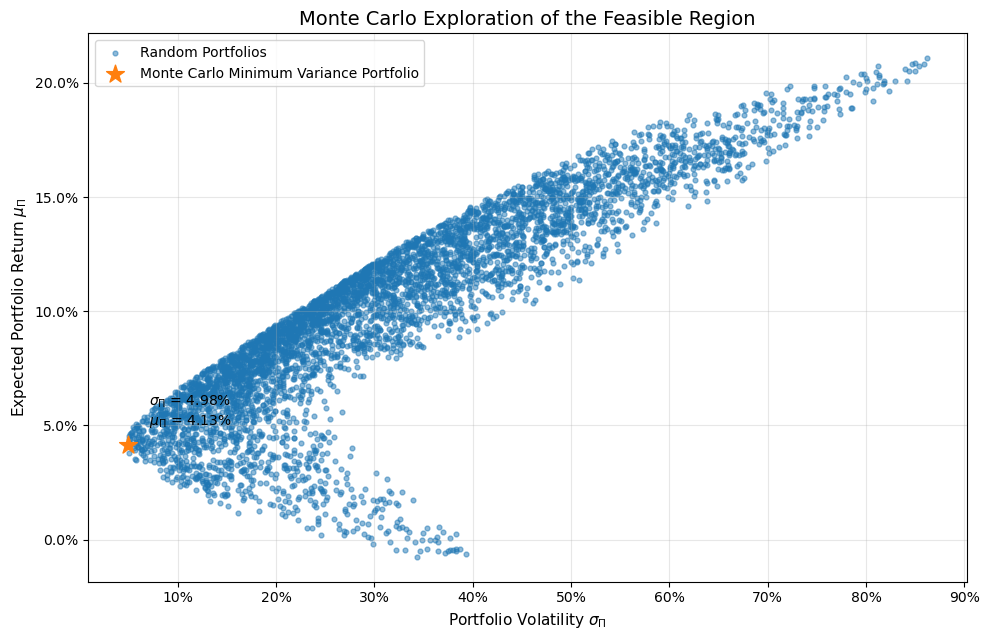


=== Monte Carlo Minimum Variance Portfolio ===
Portfolio Volatility: 4.98%
Expected Return:      4.13%


In [79]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

# Asset Information
mu = np.array([0.04, 0.08, 0.06, 0.10])
sigma = np.array([0.05, 0.20, 0.12, 0.25])
rho = np.array([
    [1.00, 0.20, 0.15, 0.05],
    [0.20, 1.00, 0.60, 0.40],
    [0.15, 0.60, 1.00, 0.30],
    [0.05, 0.40, 0.30, 1.00]
])
asset_names = ["Bonds", "Equity", "Real Estate", "Commodities"]

# Covariance Matrix
sigma_diag = np.diag(sigma)
Sigma = sigma_diag @ rho @ sigma_diag
print("=== Covariance Matrix ===")
print(Sigma.round(6))

# Monte Carlo Simulation
np.random.seed(42)
N = 5000
portfolio_returns = np.zeros(N)
portfolio_vols = np.zeros(N)
weights = np.zeros((N, 4))

for i in range(N):

    # Randomly generate the first three portfolio weights
    w1 = np.random.uniform(-1, 1)
    w2 = np.random.uniform(-1, 1)
    w3 = np.random.uniform(-1, 1)

    # Compute the fourth weight so that all weights sum to 1
    w4 = 1 - w1 - w2 - w3

    # Create the portfolio weight vector
    w = np.array([w1, w2, w3, w4])

    # Store the portfolio weights
    weights[i] = w

    # Portfolio expected return: μΠ = w'μ
    portfolio_returns[i] = w @ mu

    # Portfolio volatility: σΠ = sqrt(w'Σw)
    portfolio_vols[i] = np.sqrt(w.T @ Sigma @ w)

# Find the Monte Carlo Minimum-Variance Portfolio
min_index = np.argmin(portfolio_vols)
min_vol = portfolio_vols[min_index]
min_return = portfolio_returns[min_index]
min_weights = weights[min_index]

# Plot the Feasible Region

plt.figure(figsize=(10, 6.5))

# Random portfolios
plt.scatter(
    portfolio_vols,
    portfolio_returns,
    s=12,
    alpha=0.5,
    label="Random Portfolios"
)

# Minimum-variance portfolio
plt.scatter(
    min_vol,
    min_return,
    s=180,
    marker="*",
    label="Monte Carlo Minimum Variance Portfolio",
    zorder=3
)

# Annotate the minimum-variance portfolio
plt.annotate(
    rf"$\sigma_\Pi$ = {min_vol:.2%}" + "\n" +
    rf"$\mu_\Pi$ = {min_return:.2%}",
    xy=(min_vol, min_return),
    xytext=(15, 15),
    textcoords="offset points",
    fontsize=10
)

# Axis labels
plt.xlabel(
    r"Portfolio Volatility $\sigma_\Pi$",
    fontsize=11
)

plt.ylabel(
    r"Expected Portfolio Return $\mu_\Pi$",
    fontsize=11
)

# Title
plt.title(
    "Monte Carlo Exploration of the Feasible Region",
    fontsize=14
)

# Format both axes as percentages
plt.gca().xaxis.set_major_formatter(
    PercentFormatter(1.0)
)

plt.gca().yaxis.set_major_formatter(
    PercentFormatter(1.0)
)

# Grid and legend
plt.grid(alpha=0.3)
plt.legend()

# Adjust spacing
plt.tight_layout()

plt.show()

# Display the Minimum-Variance Portfolio Results
print("\n=== Monte Carlo Minimum Variance Portfolio ===")
print(f"Portfolio Volatility: {min_vol:.2%}")
print(f"Expected Return:      {min_return:.2%}")


=== a) VaR Backtesting Results ===
Eligible Comparisons (T): 622
Number of Breaches (B):   19
Breach Percentage:        3.05%

=== b) VaR Breaches Visually===


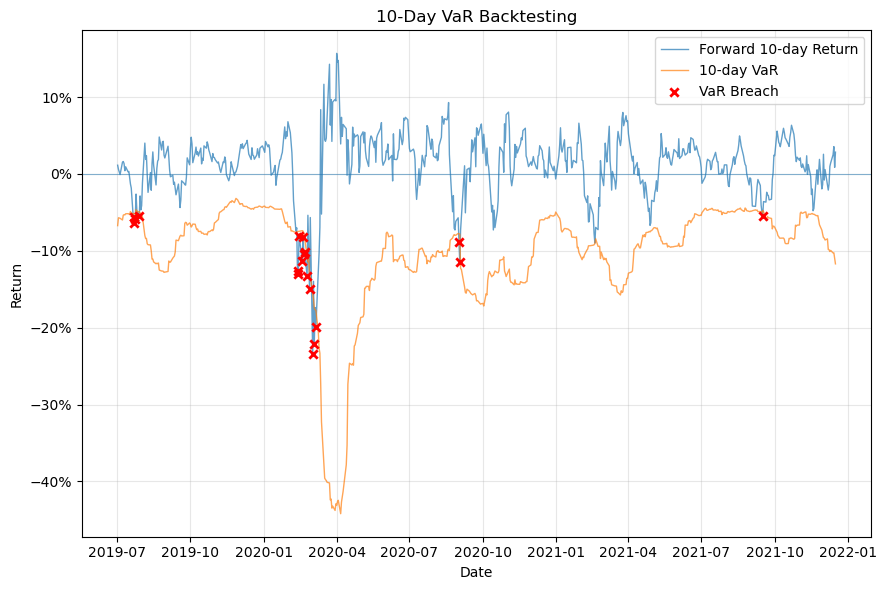


=== c) VaR Traffic-Light Test ===
Green Zone:  0 - 10 breaches
Yellow Zone: 11 - 16 breaches
Red Zone:    17 or more breaches

Observed Breaches: 19
Traffic-Light Zone: Red


In [80]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from matplotlib.ticker import PercentFormatter
from scipy.stats import binom

# 1. Import and Prepare the Data
# Read the NASDAQ-100 price data
df = pd.read_csv("E1_NASDAQ100_mid2019_2021.csv")

# Convert Date column into datetime format
df["Date"] = pd.to_datetime(
    df["Date"],
    dayfirst=True
)
# Sort observations chronologically and use Date as the index
df = df.sort_values("Date")
df = df.set_index("Date")
# Create a separate dataframe for VaR backtesting
backtest = df.copy()

# Compute Daily Returns and Rolling Volatility
# Calculate daily logarithmic returns
backtest["daily_return"] = np.log(backtest["Closing Price"]/backtest["Closing Price"].shift(1))
# Calculate the rolling standard deviation using 21 daily returns
backtest["Rolling_vol"] = backtest["daily_return"].rolling(window=21).std()

# Compute the 10-Day VaR
factor = norm.ppf(0.01)
# Scale daily volatility to 10-day volatility using sqrt(10)
backtest["VaR_10D"] = (factor * backtest["Rolling_vol"] * np.sqrt(10))
backtest["Forward_10D_Return"] = np.log(
    backtest["Closing Price"].shift(-10)/backtest["Closing Price"])
# Remove observations for which rolling volatilityabc
backtest = backtest.dropna(
    subset = ["Rolling_vol",
              "VaR_10D","Forward_10D_Return"]).copy()
# A breach occurs when the actual forward 10-day return is below the estimated 10-day VaR
backtest["Breach"] = (
    backtest["Forward_10D_Return"]<backtest["VaR_10D"])

T = len(backtest)
breach_count = int(backtest["Breach"].sum())
breach_percentage = (breach_count/T)

# Display Part (a) results
print("\n=== a) VaR Backtesting Results ===")
print(f"Eligible Comparisons (T): {T}")
print(f"Number of Breaches (B):   {breach_count}")
print(f"Breach Percentage:        {breach_percentage:.2%}")

# Keep only observations where a VaR breach occurred
breaches = backtest[backtest["Breach"]].copy()
plt.figure(figsize = (9,6))

# Plot the actual forward 10-day returns
plt.plot(
    backtest.index,
    backtest["Forward_10D_Return"],
    linewidth=1,
    alpha=0.7,
    label="Forward 10-day Return"
)

# Plot the estimated 10-day VaR
plt.plot(
    backtest.index,
    backtest["VaR_10D"],
    linewidth=1,
    alpha=0.7,
    label="10-day VaR")

# Mark VaR breaches with crosses
plt.scatter(
    breaches.index,
    breaches["Forward_10D_Return"],
    marker="x",
    label="VaR Breach",
    linewidth=2,
    zorder=3,
    color = "red"
)

# Add a zero-return reference line
plt.axhline(
    y=0,
    linewidth=0.8,
    alpha=0.5
)
# Format the graph
plt.xlabel("Date")
plt.ylabel("Return")
plt.title("10-Day VaR Backtesting")

# Display returns as percentages
plt.gca().yaxis.set_major_formatter(
    PercentFormatter(1.0)
)

plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
print("\n=== b) VaR Breaches Visually===")
plt.show()

#Traffic-Light Test
# Under a correct 99% VaR model, the number of breaches follows a Binomial distribution
# determines where the Yellow Zone begins
yellow_start = int(
    binom.ppf(0.95,T,0.01)
)

red_start = int(
    binom.ppf(0.9999,T,0.01)
)

# Classify the observed number of breaches
if breach_count < yellow_start:
    zone = "Green"
elif breach_count < red_start:
    zone = "Yellow"
else:
    zone = "Red"

# Display results
print("\n=== c) VaR Traffic-Light Test ===")
print(f"Green Zone:  "f"0 - {yellow_start - 1} breaches")
print(f"Yellow Zone: "f"{yellow_start} - {red_start - 1} breaches")
print(f"Red Zone:    "f"{red_start} or more breaches")
print(f"\nObserved Breaches: {breach_count}")
print(f"Traffic-Light Zone: {zone}")


=== a) EWMA VaR Forecast Results ===
Eligible Comparisons (T): 642
Number of Breaches (B):   27
Breach Percentage:        4.21%

=== b) EWMA VaR Breaches Visually ===


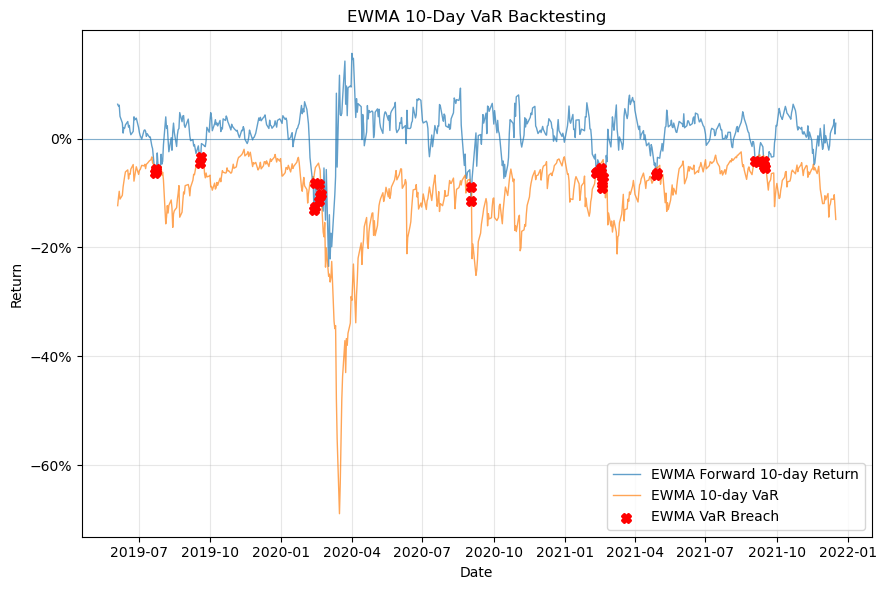

In [81]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm
from matplotlib.ticker import PercentFormatter

# Copy the original dataset
ewma_df = df.copy()

# Calculate daily log returns
ewma_df["EWMA_daily_return"] = np.log(
    ewma_df["Closing Price"] /
    ewma_df["Closing Price"].shift(1)
)

# Initialize EWMA variance using the variance of the dataset
ewma_df["EWMA_variance"] = np.nan
initial_variance = ewma_df["EWMA_daily_return"].dropna().var()

# Keep dates with valid daily returns
valid_dates = ewma_df.index[
    ewma_df["EWMA_daily_return"].notna()
]

# EWMA decay factor
lambda_ewma = 0.72

previous_var = initial_variance

# Set the initial EWMA variance
ewma_df.at[
    valid_dates[0],
    "EWMA_variance"
] = previous_var


# Apply the EWMA variance recursion
for i in range(1, len(valid_dates)):

    current_return = ewma_df.at[
        valid_dates[i],
        "EWMA_daily_return"
    ]

    # σ²(t+1|t) = λσ²(t|t-1) + (1-λ)r²_t
    current_var = (
        lambda_ewma * previous_var
        + (1 - lambda_ewma) * current_return**2
    )

    ewma_df.at[
        valid_dates[i],
        "EWMA_variance"
    ] = current_var

    # Update variance for the next iteration
    previous_var = current_var


# Convert EWMA variance to volatility
ewma_df["EWMA_vol"] = np.sqrt(
    ewma_df["EWMA_variance"]
)

# Compute the 99% 10-day EWMA VaR
factor = norm.ppf(0.01)

ewma_df["EWMA_VaR_10D"] = (
    factor
    * ewma_df["EWMA_vol"]
    * np.sqrt(10)
)

# Calculate forward 10-day log returns
ewma_df["EWMA_Forward_10D_Return"] = np.log(
    ewma_df["Closing Price"].shift(-10) /
    ewma_df["Closing Price"]
)

# Remove observations without valid VaR or forward returns
ewma_df = ewma_df.dropna(
    subset=[
        "EWMA_vol",
        "EWMA_VaR_10D",
        "EWMA_Forward_10D_Return"
    ]
).copy()

# Identify VaR breaches
ewma_df["EWMA_Breach"] = (
    ewma_df["EWMA_Forward_10D_Return"]
    < ewma_df["EWMA_VaR_10D"]
)


# Calculate breach count and percentage
EWMA_T = len(ewma_df)

EWMA_breach_count = int(
    ewma_df["EWMA_Breach"].sum()
)

EWMA_breach_percentage = (
    EWMA_breach_count / EWMA_T
)

print("\n=== a) EWMA VaR Forecast Results ===")
print(f"Eligible Comparisons (T): {EWMA_T}")
print(f"Number of Breaches (B):   {EWMA_breach_count}")
print(f"Breach Percentage:        {EWMA_breach_percentage:.2%}")

ewma_df.head()


# Keep only breach observations for plotting
ewma_breaches = ewma_df[
    ewma_df["EWMA_Breach"]
].copy()

plt.figure(figsize=(9, 6))

# Plot forward 10-day returns
plt.plot(
    ewma_df.index,
    ewma_df["EWMA_Forward_10D_Return"],
    linewidth=1,
    alpha=0.7,
    label="EWMA Forward 10-day Return"
)

# Plot EWMA 10-day VaR
plt.plot(
    ewma_df.index,
    ewma_df["EWMA_VaR_10D"],
    linewidth=1,
    alpha=0.7,
    label="EWMA 10-day VaR"
)

# Mark VaR breaches
plt.scatter(
    ewma_breaches.index,
    ewma_breaches["EWMA_Forward_10D_Return"],
    marker="X",
    label="EWMA VaR Breach",
    linewidth=2,
    zorder=3,
    color="red"
)

# Add zero-return reference line
plt.axhline(
    y=0,
    linewidth=0.8,
    alpha=0.5
)

plt.xlabel("Date")
plt.ylabel("Return")
plt.title("EWMA 10-Day VaR Backtesting")

plt.gca().yaxis.set_major_formatter(
    PercentFormatter(1.0)
)

plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()

print("\n=== b) EWMA VaR Breaches Visually ===")
plt.show()